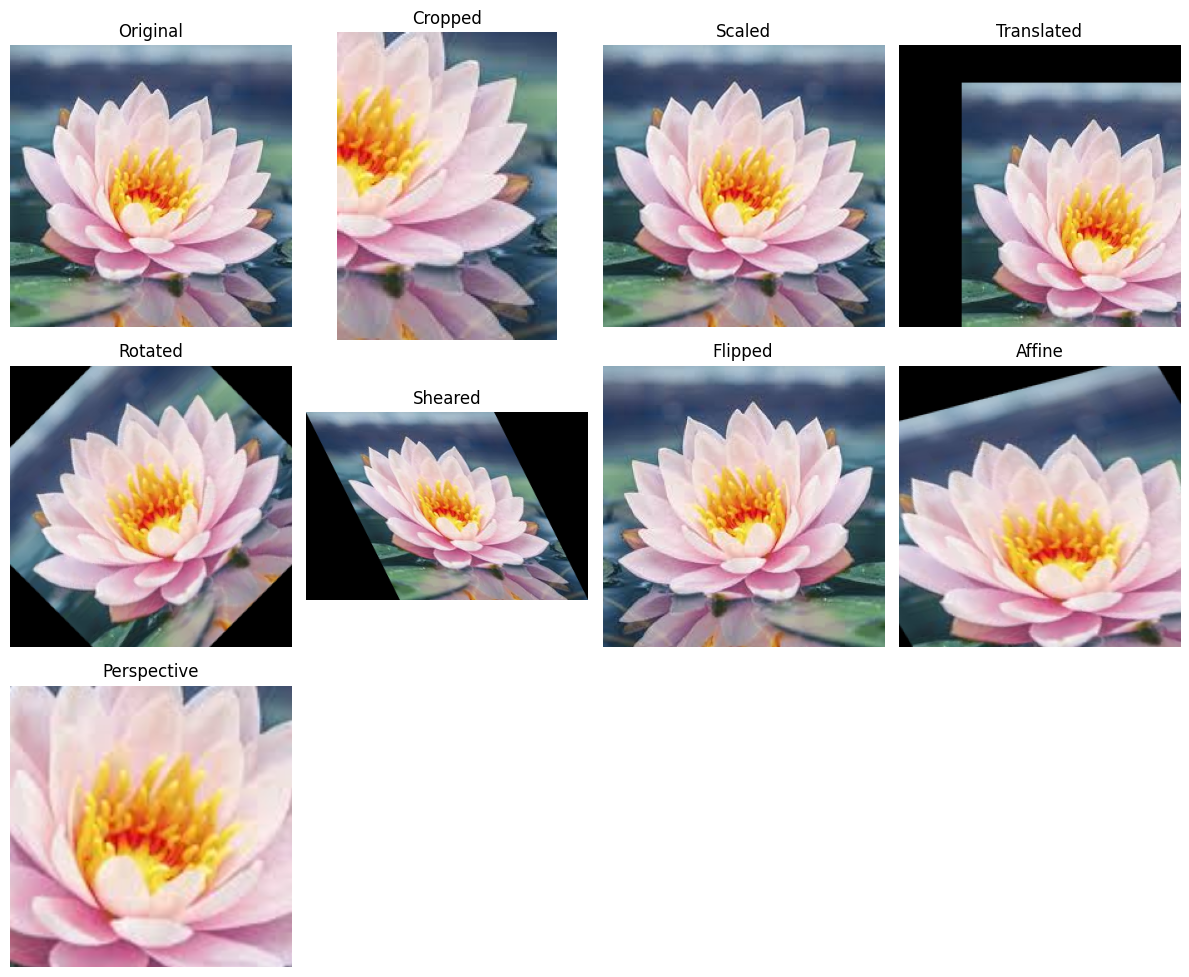

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read Image
# -----------------------------
img = cv2.imread("lotus.jpg")
assert img is not None, "Image not found"

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rows, cols = img.shape[:2]

plt.figure(figsize=(12,10))

# -----------------------------
# Original Image
# -----------------------------
plt.subplot(3,4,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

# -----------------------------
# 2. Cropping
# -----------------------------
cropped = img[50:300, 100:400]
plt.subplot(3,4,2)
plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title("Cropped")
plt.axis("off")

# -----------------------------
# 3. Scaling (Resize)
# -----------------------------
scaled = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
plt.subplot(3,4,3)
plt.imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
plt.title("Scaled")
plt.axis("off")

# -----------------------------
# 4. Translation
# -----------------------------
M_trans = np.float32([[1, 0, 50],
                      [0, 1, 30]])
translated = cv2.warpAffine(img, M_trans, (cols, rows))
plt.subplot(3,4,4)
plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.title("Translated")
plt.axis("off")

# -----------------------------
# 5. Rotation
# -----------------------------
M_rot = cv2.getRotationMatrix2D((cols//2, rows//2), 45, 1)
rotated = cv2.warpAffine(img, M_rot, (cols, rows))
plt.subplot(3,4,5)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated")
plt.axis("off")

# -----------------------------
# 6. Shearing
# -----------------------------
M_shear = np.float32([[1, 0.5, 0],
                      [0, 1, 0]])
sheared = cv2.warpAffine(img, M_shear, (int(cols*1.5), rows))
plt.subplot(3,4,6)
plt.imshow(cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB))
plt.title("Sheared")
plt.axis("off")

# -----------------------------
# 7. Reflection (Flip)
# -----------------------------
flipped = cv2.flip(img, 1)
plt.subplot(3,4,7)
plt.imshow(cv2.cvtColor(flipped, cv2.COLOR_BGR2RGB))
plt.title("Flipped")
plt.axis("off")

# -----------------------------
# 8. Affine Transformation
# -----------------------------
pts1 = np.float32([[50,50], [200,50], [50,200]])
pts2 = np.float32([[10,100], [200,50], [100,250]])
M_aff = cv2.getAffineTransform(pts1, pts2)
affine = cv2.warpAffine(img, M_aff, (cols, rows))
plt.subplot(3,4,8)
plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
plt.title("Affine")
plt.axis("off")

# -----------------------------
# 9. Perspective Transformation
# -----------------------------
pts1 = np.float32([[50,50], [cols-50,50], [50,rows-50], [cols-50,rows-50]])
pts2 = np.float32([[0,0], [300,0], [0,300], [300,300]])
M_pers = cv2.getPerspectiveTransform(pts1, pts2)
perspective = cv2.warpPerspective(img, M_pers, (300,300))
plt.subplot(3,4,9)
plt.imshow(cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB))
plt.title("Perspective")
plt.axis("off")

plt.tight_layout()
plt.show()
